# BINN Pipeline Data Engineering

This notebook performs data engineering mappings for the BINN pipeline:
1. Load SNP genotype matrix and sample/SNP indices
2. Load SNP→Gene adjacency (sparse)
3. Download Reactome GMT and build Gene→Pathway adjacency
4. Download Reactome relations and build Pathway→Pathway hierarchy

All outputs (.npz and .json) are saved for downstream use.

In [1]:
import json
import io
import zipfile
import requests
import numpy as np
import scipy.sparse as sp

def load_genotype_data():
    """Load genotype matrix and SNP-gene adjacency."""
    data = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    X = data['matrix']
    snp_list = data['snps'][:X.shape[1]].tolist()
    sample_list = data['samples'][:X.shape[0]].tolist()
    snp_gene = sp.load_npz('sparse_matrix.npz')
    return X, snp_list, sample_list, snp_gene

def download_reactome_data():
    """Download and parse Reactome GMT and relations."""
    # GMT data
    gmt_resp = requests.get('https://reactome.org/download/current/ReactomePathways.gmt.zip')
    gmt_resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(gmt_resp.content)) as z:
        gmt_file = next(fn for fn in z.namelist() if fn.endswith('.gmt'))
        gmt_text = z.read(gmt_file).decode('utf-8')
    
    # Relations data
    hier_resp = requests.get('https://reactome.org/download/current/ReactomePathwaysRelation.txt')
    hier_resp.raise_for_status()
    
    return gmt_text, hier_resp.text.strip().splitlines()

def build_gene_pathway_matrix(gmt_text, gene_index):
    """Build gene-pathway adjacency matrix from GMT."""
    pathway_ids, genesets = [], []
    for line in gmt_text.splitlines():
        parts = line.split('\t')
        pathway_ids.append(parts[0].split()[0])
        genesets.append(parts[2:])
    
    path_index = {p: i for i, p in enumerate(pathway_ids)}
    rows, cols = [], []
    for j, genes in enumerate(genesets):
        for g in genes:
            if g in gene_index:
                rows.append(gene_index[g])
                cols.append(j)
    
    gene_pathway = sp.csr_matrix((np.ones(len(rows)), (rows, cols)),
                                shape=(len(gene_index), len(pathway_ids)))
    return gene_pathway, path_index

def build_pathway_hierarchy(relations_lines, path_index):
    """Build pathway hierarchy matrix from relations."""
    rows, cols = [], []
    for line in relations_lines:
        parent, child = line.split('\t')
        if parent in path_index and child in path_index:
            rows.append(path_index[child])
            cols.append(path_index[parent])
    
    return sp.csr_matrix((np.ones(len(rows)), (rows, cols)),
                        shape=(len(path_index), len(path_index)))

def save_results(gene_pathway, pathway_hierarchy, path_index):
    """Save all matrices and indices."""
    sp.save_npz('gene_pathway_matrix.npz', gene_pathway)
    sp.save_npz('pathway_hierarchy.npz', pathway_hierarchy)
    with open('pathway_index.json', 'w') as f:
        json.dump(path_index, f, indent=2)

def main():
    """Run complete BINN data engineering pipeline."""
    print("Loading genotype data...")
    X, snp_list, sample_list, snp_gene = load_genotype_data()
    print(f"Genotype: {X.shape}, SNP→Gene: {snp_gene.shape}")
    
    print("Loading gene index...")
    with open('gene_index.json') as f:
        gene_index = json.load(f)
    
    print("Downloading Reactome data...")
    gmt_text, relations_lines = download_reactome_data()
    
    print("Building gene-pathway matrix...")
    gene_pathway, path_index = build_gene_pathway_matrix(gmt_text, gene_index)
    print(f"Gene→Pathway: {gene_pathway.shape}")
    
    print("Building pathway hierarchy...")
    pathway_hierarchy = build_pathway_hierarchy(relations_lines, path_index)
    print(f"Pathway→Pathway: {pathway_hierarchy.shape}")
    
    print("Saving results...")
    save_results(gene_pathway, pathway_hierarchy, path_index)
    print("Pipeline complete.")

if __name__ == "__main__":
    main()

Loading genotype data...
Genotype: (50, 100), SNP→Gene: (100, 122)
Loading gene index...
Building gene-pathway matrix...
Gene→Pathway: (122, 2785)
Building pathway hierarchy...
Pathway→Pathway: (1151, 1151)
Saving results...
Pipeline complete.


# BINN DATA FLOW 

In [10]:
import json
import numpy as np
import pandas as pd
from scipy import sparse

def create_individual_layers():
    """
    Create separate individual layers - no pre-multiplication
    Each layer gets its own weights in the neural network
    """
    
    # Load raw connectivity matrices (no multiplication)
    snp_gene_matrix = sparse.load_npz('sparse_matrix.npz')
    gene_pathway_matrix = sparse.load_npz('gene_pathway_matrix_fixed.npz')
    pathway_hierarchy = sparse.load_npz('pathway_hierarchy_fixed.npz')
    
    # Load indices
    with open('snp_index.json') as f:
        snp_index = json.load(f)
    with open('gene_index.json') as f:
        gene_index = json.load(f)
    with open('pathway_index_fixed.json') as f:
        pathway_index = json.load(f)
    
    # ===============================
    # LAYER 1: SNP Layer (Input)
    # ===============================
    snp_names = list(snp_index.keys())
    layer1_df = pd.DataFrame(
        index=snp_names,
        columns=['snp_features']  # Just identifiers, NN learns weights
    )
    layer1_df['snp_features'] = 1  # Identity - each SNP is itself
    
    print(f"Layer 1 (SNPs): {len(snp_names)} features")
    
    # ===============================
    # LAYER 2: Gene Layer  
    # ===============================
    gene_names = list(gene_index.keys())
    # Filter valid genes
    valid_genes = [g for g in gene_names if not g.startswith('ENSG') and len(g) <= 15]
    
    layer2_df = pd.DataFrame(
        index=valid_genes,
        columns=['gene_features']
    )
    layer2_df['gene_features'] = 1  # Identity - each gene is itself
    
    print(f"Layer 2 (Genes): {len(valid_genes)} features")
    
    # ===============================
    # LAYER 3: Pathway Layer
    # ===============================
    pathway_names = list(pathway_index.keys())
    
    layer3_df = pd.DataFrame(
        index=pathway_names,
        columns=['pathway_features']
    )
    layer3_df['pathway_features'] = 1  # Identity - each pathway is itself
    
    print(f"Layer 3 (Pathways): {len(pathway_names)} features")
    
    # ===============================
    # CONNECTIVITY MATRICES (for NN structure)
    # ===============================
    
    # These define HOW layers connect, but don't pre-multiply
    connectivity = {
        'snp_to_gene': snp_gene_matrix,
        'gene_to_pathway': gene_pathway_matrix, 
        'pathway_to_pathway': pathway_hierarchy
    }
    
    # Save individual layers
    layer1_df.to_pickle('layer1_snps.pkl')
    layer2_df.to_pickle('layer2_genes.pkl') 
    layer3_df.to_pickle('layer3_pathways.pkl')
    
    # Save connectivity (for NN architecture definition)
    for name, matrix in connectivity.items():
        sparse.save_npz(f'connectivity_{name}.npz', matrix)
    
    print("\n✅ Created individual layers:")
    print("  - layer1_snps.pkl")  
    print("  - layer2_genes.pkl")
    print("  - layer3_pathways.pkl")
    print("  - connectivity_*.npz (for NN structure)")
    
    return layer1_df, layer2_df, layer3_df, connectivity

def load_individual_layers():
    """Load the individual layer data"""
    
    layer1 = pd.read_pickle('layer1_snps.pkl')
    layer2 = pd.read_pickle('layer2_genes.pkl')
    layer3 = pd.read_pickle('layer3_pathways.pkl')
    
    connectivity = {}
    for name in ['snp_to_gene', 'gene_to_pathway', 'pathway_to_pathway']:
        connectivity[name] = sparse.load_npz(f'connectivity_{name}.npz')
    
    return layer1, layer2, layer3, connectivity

if __name__ == '__main__':
    # Create clean individual layers
    layers = create_individual_layers()
    print("\n🎯 Ready for neural network with individual layer weights!")

Layer 1 (SNPs): 100 features
Layer 2 (Genes): 103 features
Layer 3 (Pathways): 2785 features

✅ Created individual layers:
  - layer1_snps.pkl
  - layer2_genes.pkl
  - layer3_pathways.pkl
  - connectivity_*.npz (for NN structure)

🎯 Ready for neural network with individual layer weights!


# Individual Layers BINN Architecture

## Overview
Creates **separate neural network layers** with no pre-multiplication. Each layer learns weights from scratch using biological connectivity as structural constraints only.

---

## Layer Structure

### 🧬 Layer 1: SNP Features
- **Input:** Raw SNP identities (identity matrix)
- **Shape:** `(n_snps, 1)`
- **Processing:** NN learns `W₁ × SNP_features`
- **Constraints:** No biological preprocessing

### 🧪 Layer 2: Gene Features  
- **Input:** Raw gene identities (identity matrix)
- **Shape:** `(n_genes, 1)`
- **Processing:** NN learns `W₂ × Gene_features`
- **Constraints:** Connectivity guides which SNPs→Genes can connect

### 🔬 Layer 3: Pathway Features
- **Input:** Raw pathway identities (identity matrix) 
- **Shape:** `(n_pathways, 1)`
- **Processing:** NN learns `W₃ × Pathway_features`
- **Constraints:** Connectivity guides Gene→Pathway and Pathway→Pathway connections

---

## Implementation

```python
# Layer creation - NO pre-multiplication
layer1_df = pd.DataFrame(index=snp_names, columns=['snp_features'])
layer1_df['snp_features'] = 1  # Identity only

layer2_df = pd.DataFrame(index=gene_names, columns=['gene_features']) 
layer2_df['gene_features'] = 1  # Identity only

layer3_df = pd.DataFrame(index=pathway_names, columns=['pathway_features'])
layer3_df['pathway_features'] = 1  # Identity only

Training Process

Initialize: W₁, W₂, W₃ weights randomly
Train: Backpropagation learns weights from scratch
Constrain: Connectivity matrices act as masks (only train allowed connections)
Result: No biological features pre-computed

In [21]:
# Fixed BINN training for individual layers - no pre-multiplication
from binn import BINN, BINNDataLoader, BINNTrainer
import pandas as pd
import numpy as np
import json
from scipy import sparse

def load_individual_layers_for_binn():
    """Load individual layer data for BINN - no pre-computed connections"""
    
    # Load individual layers (identity matrices only)
    layer1_snps = pd.read_pickle('layer1_snps.pkl')
    layer2_genes = pd.read_pickle('layer2_genes.pkl') 
    layer3_pathways = pd.read_pickle('layer3_pathways.pkl')
    
    # Load connectivity matrices (architecture only)
    snp_to_gene = sparse.load_npz('connectivity_snp_to_gene.npz')
    gene_to_pathway = sparse.load_npz('connectivity_gene_to_pathway.npz')
    pathway_to_pathway = sparse.load_npz('connectivity_pathway_to_pathway.npz')
    
    # Load indices
    with open('snp_index.json') as f:
        snp_index = json.load(f)
    with open('gene_index.json') as f:
        gene_index = json.load(f)
    with open('pathway_index_fixed.json') as f:
        pathway_index = json.load(f)
    
    # Create mapping DataFrame for BINN (Layer 1 → Layer 2)
    mapping_data = []
    snp_names = list(snp_index.keys())
    gene_names = list(gene_index.keys())
    
    # SNP→Gene connections from connectivity matrix
    snp_gene_coo = snp_to_gene.tocoo()
    for i, j in zip(snp_gene_coo.row, snp_gene_coo.col):
        if i < len(snp_names) and j < len(gene_names):
            mapping_data.append({
                'input': snp_names[i],
                'translation': gene_names[j]
            })
    
    mapping_df = pd.DataFrame(mapping_data)
    
    # Create pathways DataFrame (Layer 2 → Layer 3)
    pathway_data = []
    pathway_names = list(pathway_index.keys())
    
    # Gene→Pathway connections
    gene_pathway_coo = gene_to_pathway.tocoo()
    for i, j in zip(gene_pathway_coo.row, gene_pathway_coo.col):
        if i < len(gene_names) and j < len(pathway_names):
            pathway_data.append({
                'source': gene_names[i],
                'target': pathway_names[j]
            })
    
    # Pathway→Pathway hierarchy
    pathway_pathway_coo = pathway_to_pathway.tocoo()
    for i, j in zip(pathway_pathway_coo.row, pathway_pathway_coo.col):
        if i < len(pathway_names) and j < len(pathway_names):
            pathway_data.append({
                'source': pathway_names[i],
                'target': pathway_names[j]
            })
    
    pathways_df = pd.DataFrame(pathway_data)
    
    return mapping_df, pathways_df

def create_individual_datamatrix():
    """Create datamatrix with individual SNP features (no pre-multiplication)"""
    
    # Load raw genotype data
    genotype_data = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    genotype_matrix = genotype_data['matrix']  # (samples, snps)
    samples = genotype_data['samples'][:genotype_matrix.shape[0]]
    
    # Load SNP names
    with open('snp_index.json') as f:
        snp_index = json.load(f)
    snp_names = list(snp_index.keys())
    
    # Create datamatrix: SNPs as rows, samples as columns
    # Each SNP gets its raw genotype values (no biological preprocessing)
    datamatrix = pd.DataFrame(
        genotype_matrix.T,  # Transpose: (snps, samples)
        index=snp_names[:genotype_matrix.shape[1]],
        columns=samples
    )
    
    # Add required Protein column
    datamatrix.reset_index(inplace=True)
    datamatrix.rename(columns={'index': 'Protein'}, inplace=True)
    
    return datamatrix

def create_design_matrix(samples):
    """Create design matrix with labels"""
    # Replace with your actual labels
    return pd.DataFrame({
        'sample': samples,
        'group': np.random.choice(['case', 'control'], len(samples)),
        'target': np.random.randint(0, 2, len(samples))
    })

# Main training pipeline
def train_individual_layers_binn():
    """Train BINN with individual layers - no pre-computation"""
    
    print("Loading individual layers...")
    mapping_df, pathways_df = load_individual_layers_for_binn()
    datamatrix = create_individual_datamatrix()
    
    print(f"SNP features: {len(datamatrix)}")
    print(f"SNP→Gene mappings: {len(mapping_df)}")
    print(f"Gene/Pathway→Pathway mappings: {len(pathways_df)}")
    
    # Create design matrix
    samples = datamatrix.columns[1:].tolist()  # Exclude 'Protein'
    designmatrix = create_design_matrix(samples)
    
    # BINN parameters
    binn_params = {
        'data_matrix': datamatrix,
        'mapping': mapping_df,
        'pathways': pathways_df,
        'device': "cpu",
        'n_outputs': 2,
        'n_layers': 3,  # SNP → Gene → Pathway
        'activation': "tanh",
        'input_col': "input",
        'target_col': "target",
        'entity_col': "Protein",
        'source_col': "source",
        'translation_col': "translation"
    }
    
    # Initialize BINN
    print("Initializing BINN with individual layers...")
    binn = BINN(**binn_params)
    
    # Create dataloaders
    binn_dataloader = BINNDataLoader(binn)
    dataloaders = binn_dataloader.create_dataloaders(
        data_matrix=datamatrix,
        design_matrix=designmatrix,
        feature_column="Protein",
        group_column="group",
        sample_column="sample",
        batch_size=16,
        validation_split=0.2
    )
    
    # Train
    print("Training BINN...")
    trainer = BINNTrainer(binn)
    trainer.fit(dataloaders=dataloaders, num_epochs=10)
    
    print("✅BINN training complete!")
    
    
    return binn, trainer

if __name__ == "__main__":
    # Run individual layers training
    trained_binn, trainer = train_individual_layers_binn()

Loading individual layers...
SNP features: 100
SNP→Gene mappings: 130
Gene/Pathway→Pathway mappings: 2792
Initializing BINN with individual layers...

[INFO] BINN is on device: cpu
Mapping group labels: {'case': 0, 'control': 1}
Training BINN...
[Epoch 1/10] Train Loss: 1.2416, Train Accuracy: 0.3750
[Epoch 1/10] Val Loss: 0.6932, Val Accuracy: 0.5000
[Epoch 2/10] Train Loss: 1.1235, Train Accuracy: 0.4167
[Epoch 2/10] Val Loss: 0.6934, Val Accuracy: 0.5000
[Epoch 3/10] Train Loss: 1.2870, Train Accuracy: 0.3750
[Epoch 3/10] Val Loss: 0.6933, Val Accuracy: 0.5000
[Epoch 4/10] Train Loss: 0.8467, Train Accuracy: 0.5625
[Epoch 4/10] Val Loss: 0.6938, Val Accuracy: 0.5000
[Epoch 5/10] Train Loss: 1.1927, Train Accuracy: 0.3958
[Epoch 5/10] Val Loss: 0.6935, Val Accuracy: 0.5000
[Epoch 6/10] Train Loss: 1.2504, Train Accuracy: 0.3750
[Epoch 6/10] Val Loss: 0.6932, Val Accuracy: 0.5000
[Epoch 7/10] Train Loss: 1.3293, Train Accuracy: 0.4375
[Epoch 7/10] Val Loss: 0.6933, Val Accuracy: 0.500

Mapping group labels: {'case': 0, 'control': 1}
Total connections: 864
=== TOP CONNECTIONS BY LAYER ===

Layer 0:
  rs28583821 → MTF1: 0.0618
  rs6687904 → CDC7: 0.0499
  rs6687904 → TGFBR3: 0.0499
  rs78244353 → KAZN: 0.0386
  rs6687904 → CDC7: 0.0332

Layer 1:
  MTF1 → MTF1: 0.0618
  MTF1 → Metabolism of lipids: 0.0618
  CDC7 → CDC7: 0.0475
  CDC7 → Cell Cycle Checkpoints: 0.0475
  CDC7 → Cell Cycle, Mitotic: 0.0475

Layer 2:
  MTF1 → Activation of gene expression by SREBF (SREBP): 0.0561
  MTF1 → Cellular responses to stimuli: 0.0561
  MTF1 → MTF1 activates gene expression: 0.0561
  MTF1 → Metabolism: 0.0561
  MTF1 → PPARA activates gene expression: 0.0561

Layer 3:
  Developmental Biology → output_node: 0.0405
  Metabolism → output_node: 0.0384
  Disease → output_node: 0.0300
  DNA Replication → output_node: 0.0291
  Signal Transduction → output_node: 0.0290


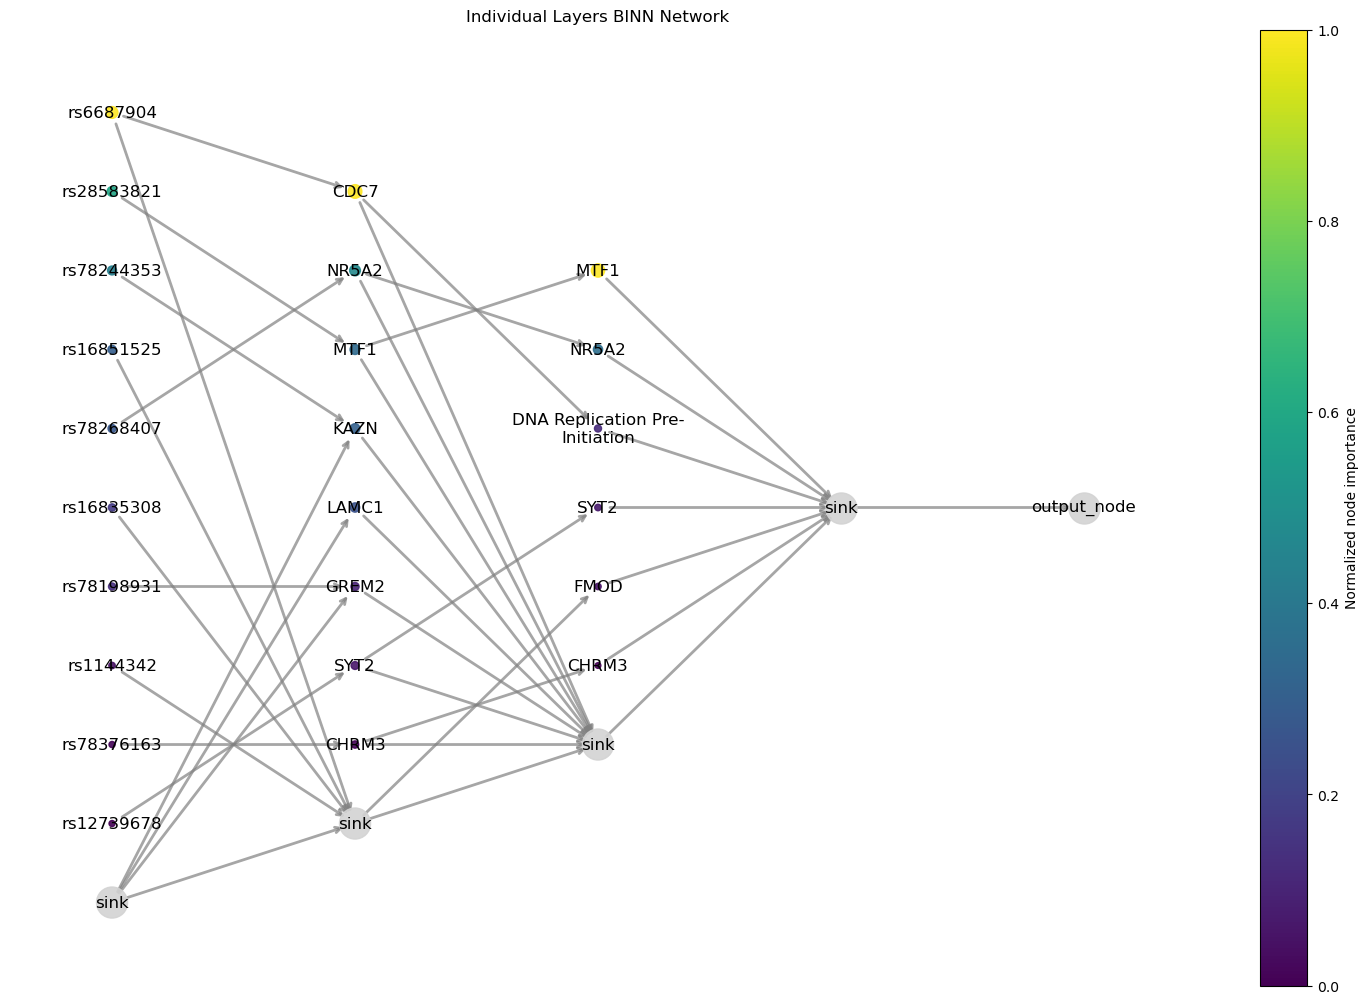

✅ BINN explanation complete!


In [24]:
# Compact BINN Explainer for Individual Layers
from binn import BINNExplainer
from binn.plot.network import visualize_binn

def explain_individual_binn(binn, method="single"):
    """Generate explanations for individual layer BINN"""
    
    # Recreate dataloaders
    from binn import BINNDataLoader
    
    datamatrix = create_individual_datamatrix()
    samples = datamatrix.columns[1:].tolist()
    designmatrix = create_design_matrix(samples)
    
    binn_dataloader = BINNDataLoader(binn)
    dataloaders = binn_dataloader.create_dataloaders(
        data_matrix=datamatrix,
        design_matrix=designmatrix,
        feature_column="Protein",
        group_column="group", 
        sample_column="sample",
        batch_size=16,
        validation_split=0.2
    )
    
    # Generate explanations
    explainer = BINNExplainer(binn)
    
    if method == "single":
        explanations = explainer.explain_single(dataloaders, normalization_method="fan")
    else:
        explanations = explainer.explain(dataloaders, nr_iterations=3, normalization_method="fan")
    
    explanations.to_csv("binn_explanations.csv", index=False)
    return explanations

def show_top_connections(explanations, n=5):
    """Display top connections by layer"""
    
    print("=== TOP CONNECTIONS BY LAYER ===")
    for layer in sorted(explanations['source_layer'].unique()):
        layer_data = explanations[explanations['source_layer'] == layer]
        top = layer_data.nlargest(n, 'importance')
        
        print(f"\nLayer {layer}:")
        for _, row in top.iterrows():
            print(f"  {row['source_node']} → {row['target_node']}: {row['importance']:.4f}")

def visualize_network(explanations):
    """Create network visualization"""
    
    plt = visualize_binn(
        explanations,
        top_n={"0": 10, "1": 8, "2": 6},
        plot_size=(15, 10),
        node_size_scaling=300,
        edge_width=2
    )
    plt.title("Individual Layers BINN Network")
    plt.show()

# Main execution
if __name__ == "__main__":
    # Generate explanations (no dataloaders needed)
    explanations = explain_individual_binn(trained_binn)
    
    # Show results
    print(f"Total connections: {len(explanations)}")
    show_top_connections(explanations)
    
    # Visualize
    visualize_network(explanations)
    
    print("✅ BINN explanation complete!")